# 04. Re-tuning the heuristic at deployment depth

Notebook 03 ran a 3-axis weight grid plus 20 random samples at `TUNING_DEPTH=2`,
re-validated the best ones at `DEFAULT_DEPTH=3`, and ended up keeping the
defaults because nothing transferred. That is a defensible result, but it is
also a worst-case for the procedure: tuning a shallow search rewards weight
vectors that paper over things the search cannot see, and at d=3 the search
sees most of them on its own. So the negative result might just be telling us
"d=2 weights do not deploy at d=3," not "the defaults are optimal."

This notebook re-runs the tuning loop with the three things I would change if
I were doing it from scratch:

1. tune at the depth we actually deploy (d=3),
2. let all five non-terminal weights vary, and
3. score each candidate against two opponents instead of one, ranking by the
   worse of the two so a candidate has to be robust rather than just lucky
   against the default agent.

If this still picks the defaults, that is a much stronger statement than
nb03's null. If it picks something else, the report has a real comparison.


In [1]:
import os, pickle, random, sys, time
from math import sqrt

import numpy as np
import pandas as pd

# Notebooks live one directory below the project root.
_here = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _here not in sys.path:
    sys.path.insert(0, _here)
import settings, tictactoe66
import experiments
from experiments import (
    run_or_load, make_spec as _spec, make_balanced_jobs,
    run_games as _exp_run_games, wilson_ci,
)

game = tictactoe66.TicTacToe66()

# Same shared-pool trick as nb03: pay the worker spawn cost once.
POOL, MAX_WORKERS = experiments.make_pool()

def run_games(jobs):
    """Notebook-local thin wrapper that injects the shared POOL."""
    return _exp_run_games(jobs, POOL, MAX_WORKERS)

# Pre-warm so the first real batch doesn't stall on numba compilation.
experiments.prewarm_pool(POOL, MAX_WORKERS)

print(f"workers: {MAX_WORKERS}")
print(f"deployment depth (DEFAULT_DEPTH): {settings.DEFAULT_DEPTH}")
print(f"defaults: {settings.DEFAULT_HEURISTIC_WEIGHTS}")


workers: 32
deployment depth (DEFAULT_DEPTH): 3
defaults: {'w_two': 1.0, 'w_three': 10.0, 'w_block_two': 1.0, 'w_block_three': 8.0, 'w_open_three': 0.0, 'w_block_open_three': 0.0, 'w_center': 0.5, 'w_win': 10000.0}


## Helpers

These mirror the ones in nb03. I copied rather than imported to keep this
notebook readable on its own.


In [2]:
# All experiment helpers (run_or_load, _spec/make_spec, make_balanced_jobs,
# run_games, wilson_ci) are imported from ../experiments.py so this notebook
# stays in sync with nb03. _spec is aliased above for backwards-compatible
# call sites; new code should prefer experiments.make_spec.


## Candidate generation

I draw 30 random weight vectors plus the default as a control. The four
"value" weights are sampled log-uniformly because their plausible range
spans roughly an order of magnitude either side of the defaults, and a
linear sample would waste resolution on the high end. `w_center` is small
to begin with, so it gets a plain uniform draw on `[0, 3]`.

Bounds are deliberately wider than the `0.5x / 1x / 2x` grid in nb03:

| weight          | default | tuning range          |
|-----------------|--------:|-----------------------|
| `w_two`         | 1.0     | log-uniform [0.2, 5]  |
| `w_three`       | 10.0    | log-uniform [3, 30]   |
| `w_block_two`   | 1.0     | log-uniform [0.2, 5]  |
| `w_block_three` | 8.0     | log-uniform [2, 30]   |
| `w_center`      | 0.5     | uniform [0, 3]        |

`w_open_three` and `w_block_open_three` were already shown to do nothing in
nb03 and `w_win` is the terminal sentinel, so all three stay fixed.


In [3]:
SEED         = settings.RANDOM_SEED
N_CANDIDATES = 30
DEPTH        = settings.DEFAULT_DEPTH

base    = settings.DEFAULT_HEURISTIC_WEIGHTS
rng_gen = np.random.default_rng(SEED)


def _log_uniform(low, high, rng):
    return float(np.exp(rng.uniform(np.log(low), np.log(high))))


def _sample_weights(rng):
    w = dict(base)
    w["w_two"]         = _log_uniform(0.2, 5.0,  rng)
    w["w_three"]       = _log_uniform(3.0, 30.0, rng)
    w["w_block_two"]   = _log_uniform(0.2, 5.0,  rng)
    w["w_block_three"] = _log_uniform(2.0, 30.0, rng)
    w["w_center"]      = float(rng.uniform(0.0, 3.0))
    return w


candidates = [("control", dict(base))]
for i in range(N_CANDIDATES):
    candidates.append((f"rand_{i:02d}", _sample_weights(rng_gen)))

VARIED = ["w_two", "w_three", "w_block_two", "w_block_three", "w_center"]
cand_df = pd.DataFrame([{"tag": tag, **{k: w[k] for k in VARIED}}
                        for tag, w in candidates])
print(f"candidates including control: {len(candidates)}")
cand_df.head()


candidates including control: 31


,tag,w_two,w_three,w_block_two,w_block_three,w_center
0,control,1.000000,10.000000,1.000000,8.000000,0.500000
1,rand_00,2.415317,8.241375,3.171746,13.218995,0.282532
2,rand_01,4.622655,17.308561,2.511312,2.829458,1.351158
3,rand_02,0.659756,25.344647,1.588967,18.564050,1.330243
4,rand_03,0.415620,10.757368,0.245608,18.810476,1.894993


### What the candidate cloud looks like

A quick look at the sample so the rest of the notebook is easier to read.
The control vector (defaults) shows up as a star; the random draws form
a cloud around it that extends well beyond nb03's grid.


saved C:\Git\AI801Project\cache\figures\exp_tune_candidates.png


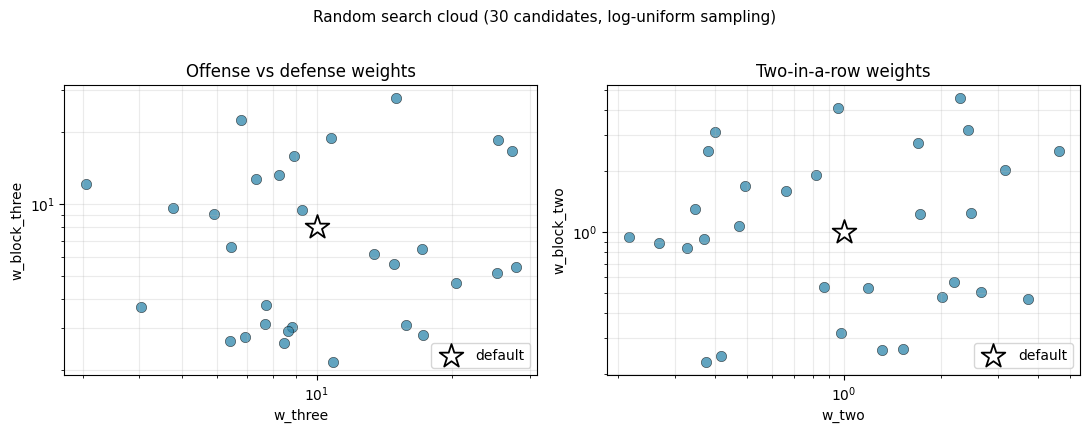

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
non_ctrl = cand_df[cand_df["tag"] != "control"]

axes[0].scatter(non_ctrl["w_three"], non_ctrl["w_block_three"],
                s=55, color="#2E86AB", alpha=0.75, edgecolor="k", linewidth=0.4)
axes[0].scatter([base["w_three"]], [base["w_block_three"]],
                marker="*", s=320, color="white", edgecolor="black",
                linewidth=1.3, label="default", zorder=5)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("w_three"); axes[0].set_ylabel("w_block_three")
axes[0].set_title("Offense vs defense weights")
axes[0].legend(loc="lower right")
axes[0].grid(True, which="both", alpha=0.25)

axes[1].scatter(non_ctrl["w_two"], non_ctrl["w_block_two"],
                s=55, color="#2E86AB", alpha=0.75, edgecolor="k", linewidth=0.4)
axes[1].scatter([base["w_two"]], [base["w_block_two"]],
                marker="*", s=320, color="white", edgecolor="black",
                linewidth=1.3, label="default", zorder=5)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("w_two"); axes[1].set_ylabel("w_block_two")
axes[1].set_title("Two-in-a-row weights")
axes[1].legend(loc="lower right")
axes[1].grid(True, which="both", alpha=0.25)

fig.suptitle(f"Random search cloud ({len(non_ctrl)} candidates, log-uniform sampling)",
             y=1.02, fontsize=11)
fig.tight_layout()
out = settings.FIGURES_DIR / "exp_tune_candidates.png"
fig.savefig(out, dpi=120, bbox_inches="tight")
print("saved", out)
plt.show()


## Opponent panel

Two opponents, both running alpha-beta at d=3:

* **default**: the shipped weights. This is the apples-to-apples comparison
  with nb03's expC.
* **aggressive**: `w_three` doubled, blocking weights halved. An opponent
  that prefers building threats over blocking. A candidate that wins only
  because the opponent over-defends will be penalized here.

Final ranking uses the mean of the two win rates. I also report the worse
of the two so it is easy to spot candidates that are exploiting one
specific opponent.


In [5]:
opponents = {
    "default": dict(base),
    "aggressive": {**base,
                   "w_three":       base["w_three"]       * 2.0,
                   "w_block_two":   base["w_block_two"]   * 0.5,
                   "w_block_three": base["w_block_three"] * 0.5},
}
for name, w in opponents.items():
    short = {k: round(w[k], 2) for k in VARIED}
    print(f"{name:>10s} -> {short}")


   default -> {'w_two': 1.0, 'w_three': 10.0, 'w_block_two': 1.0, 'w_block_three': 8.0, 'w_center': 0.5}
aggressive -> {'w_two': 1.0, 'w_three': 20.0, 'w_block_two': 0.5, 'w_block_three': 4.0, 'w_center': 0.5}


## Sweep

Each (candidate, opponent) cell plays 40 games at d=3 with sides alternated
and unique seeds per game. That gives an effective per-candidate sample of
80 games (the same as nb03's expC), just split across two opponents so the
per-candidate variance is lower.

This is the expensive cell of the notebook. At d=3 a single game is around
six seconds of CPU; 30 candidates times two opponents times 40 games
spread across the worker pool lands in roughly three to four minutes on a
modern multi-core box.


In [6]:
N_TUNING_GAMES = 40
N_PREALLOC     = 2

def expT():
    jobs = []
    for i, (tag, w) in enumerate(candidates):
        cand_spec = _spec(depth=DEPTH, weights=w)
        for j, (opp_name, opp_w) in enumerate(opponents.items()):
            opp_spec = _spec(depth=DEPTH, weights=opp_w)
            seed     = 3000 + 1000 * i + 100 * j
            jobs.extend(make_balanced_jobs(
                cand_spec, opp_spec,
                n_prealloc=N_PREALLOC,
                n_games=N_TUNING_GAMES,
                seed=seed,
                tag=(tag, opp_name)))
    print(f"  submitting {len(jobs)} games "
          f"({len(candidates)} cand x {len(opponents)} opp x {N_TUNING_GAMES} games)")
    results = run_games(jobs)
    df = pd.DataFrame(results)
    df["cand_tag"], df["opp_name"] = zip(*df["tag"])
    return df

dfT = run_or_load("expT_tuning_d3", expT)
print(f"total games: {len(dfT)}")


[run]   computing expT_tuning_d3.pkl ...
  submitting 2480 games (31 cand x 2 opp x 40 games)


        done in 227.2s
total games: 2480


### Aggregate per candidate

I compute the win rate per opponent first and then take the mean across
opponents as the headline score. The min across opponents is kept around
as a robustness check.


In [7]:
per_cell = (dfT.assign(win=lambda d: d["winner_label"] == "A")
                .groupby(["cand_tag", "opp_name"])
                .agg(wins=("win", "sum"), n=("win", "size"))
                .reset_index())
per_cell["win_rate"] = per_cell["wins"] / per_cell["n"]

per_cand = (per_cell.groupby("cand_tag")
                    .agg(mean_winrate=("win_rate", "mean"),
                         min_winrate =("win_rate", "min"),
                         max_winrate =("win_rate", "max"))
                    .reset_index()
                    .merge(cand_df, left_on="cand_tag", right_on="tag")
                    .drop(columns=["tag"])
                    .sort_values("mean_winrate", ascending=False)
                    .reset_index(drop=True))

ctrl_mean = float(per_cand.loc[per_cand["cand_tag"] == "control",
                               "mean_winrate"].iloc[0])
print(f"Control mean win rate: {ctrl_mean:.3f}  (~0.5 is healthy)")
print()
print("Top 10 by mean win rate:")
per_cand.head(10)


Control mean win rate: 0.525  (~0.5 is healthy)

Top 10 by mean win rate:


,cand_tag,mean_winrate,min_winrate,max_winrate,w_two,w_three,w_block_two,w_block_three,w_center
0,control,0.5250,0.500,0.550,1.000000,10.000000,1.000000,8.000000,0.500000
1,rand_05,0.5250,0.450,0.600,0.374217,8.787033,0.230285,3.037306,2.049147
2,rand_29,0.5125,0.475,0.550,0.472330,6.437100,1.068806,6.564927,0.064836
3,rand_26,0.5000,0.500,0.500,0.346345,25.248837,1.298131,5.116589,1.772746
4,rand_24,0.5000,0.475,0.525,1.310883,13.395775,0.262469,6.166766,0.124843
5,rand_28,0.5000,0.475,0.525,0.957964,9.285991,4.093126,9.406636,1.420468
6,rand_01,0.4875,0.450,0.525,4.622655,17.308561,2.511312,2.829458,1.351158
7,rand_27,0.4875,0.450,0.525,0.215233,27.269707,0.944629,16.657049,0.248190
8,rand_02,0.4750,0.425,0.525,0.659756,25.344647,1.588967,18.564050,1.330243
9,rand_06,0.4750,0.425,0.525,2.198684,27.837549,0.570840,5.454117,1.408667


### Distribution of candidate scores

A histogram of mean win rates across the random draws gives a feel for how
much of the space is even competitive. If the cloud sits well below 0.5,
the defaults are doing real work; if it sits at 0.5, the loss landscape is
flat and tuning can't help.


saved C:\Git\AI801Project\cache\figures\exp_tune_distribution.png


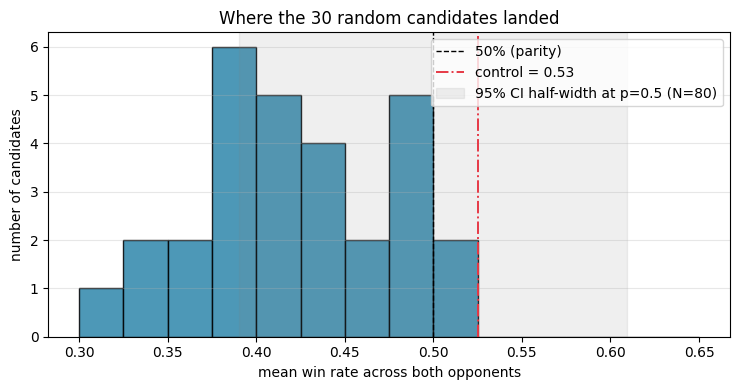

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4))

vals = per_cand[per_cand["cand_tag"] != "control"]["mean_winrate"].values
ax.hist(vals, bins=np.arange(0.30, 0.66, 0.025),
        color="#2E86AB", edgecolor="black", alpha=0.85)
ax.axvline(0.5, color="black", ls="--", lw=1.0, label="50% (parity)")
ax.axvline(ctrl_mean, color="#E63946", ls="-.", lw=1.4,
           label=f"control = {ctrl_mean:.2f}")
ax.set_xlabel("mean win rate across both opponents")
ax.set_ylabel("number of candidates")
ax.set_title(f"Where the {len(vals)} random candidates landed")
# Per-candidate Wilson half-width at the screen sample size, so the
# spread of bars is read with appropriate caution rather than as a
# crisp ranking. With 40 games per (candidate, opponent) and 2
# opponents the effective N per candidate is 80, giving:
_n_eff = N_TUNING_GAMES * len(opponents)
_halfwidth = 1.96 * (0.25 / _n_eff) ** 0.5
ax.axvspan(0.5 - _halfwidth, 0.5 + _halfwidth,
           color="gray", alpha=0.12,
           label=f"95% CI half-width at p=0.5 (N={_n_eff})")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
out = settings.FIGURES_DIR / "exp_tune_distribution.png"
fig.savefig(out, dpi=120)
print("saved", out)
plt.show()


### Per-opponent breakdown for the leaders

For the top 10 candidates, plot the win rate against each opponent
side-by-side. A candidate that beats only one opponent is suspicious; a
candidate that beats both is what we are looking for.


saved C:\Git\AI801Project\cache\figures\exp_tune_per_opponent.png


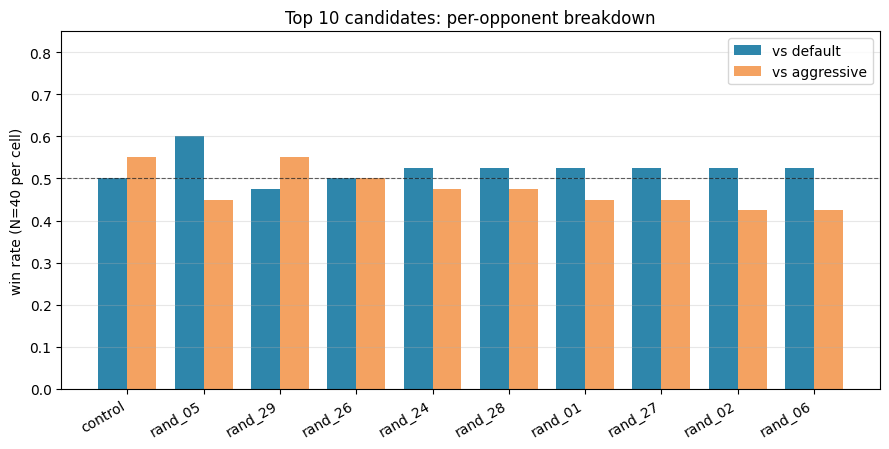

In [9]:
top10 = per_cand.head(10).copy()
opp_table = (per_cell.merge(top10[["cand_tag"]], on="cand_tag")
                     .pivot(index="cand_tag", columns="opp_name",
                            values="win_rate")
                     .reindex(top10["cand_tag"]))

fig, ax = plt.subplots(figsize=(9, 4.6))
xs    = np.arange(len(opp_table))
width = 0.38
ax.bar(xs - width/2, opp_table["default"],    width,
       color="#2E86AB", label="vs default")
ax.bar(xs + width/2, opp_table["aggressive"], width,
       color="#F4A261", label="vs aggressive")
ax.axhline(0.5, color="black", ls="--", lw=0.8, alpha=0.6)
ax.set_xticks(xs)
ax.set_xticklabels(opp_table.index, rotation=30, ha="right")
ax.set_ylabel("win rate (N=40 per cell)")
ax.set_ylim(0.0, 0.85)
ax.set_title("Top 10 candidates: per-opponent breakdown")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
out = settings.FIGURES_DIR / "exp_tune_per_opponent.png"
fig.savefig(out, dpi=120)
print("saved", out)
plt.show()


## Validation

The ranking above is noisy: 80 games per candidate gives a Wilson half-width
of about 0.11 at p=0.5, which is wide enough that picking the apparent top
is mostly selection bias. The standard fix is to re-play the leaders at a
larger N with fresh seeds and require them to clear a Bonferroni-corrected
threshold, which is what nb03's expC also did.

I take the top 5 here and replay each against the default opponent at
N=160, tightening the per-candidate Wilson half-width to about 0.078. With
K=5 the Bonferroni-adjusted alpha is 0.01, which translates to a
one-sided pass threshold of roughly 0.60 in win rate.


In [10]:
from scipy.stats import norm

# expT screen ranked candidates by mean win rate across BOTH opponents
# (default + aggressive). To stay faithful to the selection criterion,
# the validation here also plays each top-K candidate against both
# opponents -- ranking by the mean (the "headline" score) and reporting
# the per-opponent breakdown so we can spot candidates that win on
# average but get crushed by one specific opponent.
TOP_K       = 5
N_VAL_GAMES = 80   # per opponent, so total per candidate = 160

top = (per_cand[per_cand["cand_tag"] != "control"]
       .head(TOP_K)
       .reset_index(drop=True))

# Bonferroni correction across TOP_K tests at family-wise alpha=0.05.
# Threshold is computed against the *mean-of-two-opponents* statistic,
# whose per-game variance equals the per-opponent variance averaged
# across opponents. With balanced N per opponent the SE on the mean
# is sqrt(0.25 / (n_opp * N_per_opp)).
alpha_bonf = 0.05 / TOP_K
z_bonf     = norm.ppf(1 - alpha_bonf / 2)
n_total    = N_VAL_GAMES * len(opponents)
threshold  = 0.5 + z_bonf * sqrt(0.25 / n_total)
print(f"Bonferroni threshold (K={TOP_K}, N={n_total} across "
      f"{len(opponents)} opponents): mean win rate >= {threshold:.3f}")

cand_lookup = {tag: w for tag, w in candidates}

def expV():
    jobs = []
    for i, row in top.iterrows():
        cand_spec = _spec(depth=DEPTH, weights=cand_lookup[row["cand_tag"]])
        for j, (opp_name, opp_w) in enumerate(opponents.items()):
            opp_spec = _spec(depth=DEPTH, weights=opp_w)
            seed     = 50_000 + 1000 * i + 100 * j
            jobs.extend(make_balanced_jobs(
                cand_spec, opp_spec,
                n_prealloc=N_PREALLOC,
                n_games=N_VAL_GAMES,
                seed=seed,
                tag=(row["cand_tag"], opp_name)))
    print(f"  submitting {len(jobs)} validation games "
          f"({TOP_K} candidates x {len(opponents)} opponents x {N_VAL_GAMES} games)")
    df = pd.DataFrame(run_games(jobs))
    df["cand_tag"], df["opp_name"] = zip(*df["tag"])
    return df

# New cache name so the dual-opponent results don't collide with the
# legacy single-opponent expV pickle from earlier runs of this notebook.
dfV = run_or_load("expV_validation_d3_dual", expV)

# Per-(candidate, opponent) breakdown.
per_cell_v = (dfV.assign(win=lambda d: d["winner_label"] == "A")
                  .groupby(["cand_tag", "opp_name"])
                  .agg(wins=("win", "sum"), n=("win", "size"))
                  .reset_index())
per_cell_v["win_rate"] = per_cell_v["wins"] / per_cell_v["n"]

# Aggregate to mean-of-opponents (the statistic we threshold on).
val = (per_cell_v.groupby("cand_tag")
                 .agg(wins=("wins", "sum"), n=("n", "sum"),
                      mean_winrate=("win_rate", "mean"),
                      min_winrate =("win_rate", "min"))
                 .reset_index()
                 .rename(columns={"cand_tag": "tag"}))
val["win_rate"] = val["wins"] / val["n"]   # pooled win rate for the CI
val[["lo", "hi"]] = val.apply(
    lambda r: pd.Series(wilson_ci(int(r["wins"]), int(r["n"]))), axis=1)
val["passes"] = val["mean_winrate"] >= threshold
val = val.merge(top[["cand_tag", "mean_winrate"]]
                 .rename(columns={"mean_winrate": "tune_mean_winrate"}),
                left_on="tag", right_on="cand_tag").drop(columns="cand_tag")
val[["tag", "tune_mean_winrate", "mean_winrate", "min_winrate",
     "lo", "hi", "passes"]]


Bonferroni threshold (K=5, N=160 across 2 opponents): mean win rate >= 0.602
[run]   computing expV_validation_d3_dual.pkl ...
  submitting 800 validation games (5 candidates x 2 opponents x 80 games)


        done in 76.2s


,tag,tune_mean_winrate,mean_winrate,min_winrate,lo,hi,passes
0,rand_05,0.5250,0.51875,0.5125,0.441801,0.594820,False
1,rand_24,0.5000,0.47500,0.4750,0.399118,0.552055,False
2,rand_26,0.5000,0.46875,0.4625,0.393067,0.545899,False
3,rand_28,0.5000,0.38125,0.3750,0.309611,0.458458,False
4,rand_29,0.5125,0.38750,0.3625,0.315492,0.464783,False


### Tuning win rate vs validation win rate

The interesting plot here is not the validation result by itself; it is
how much each candidate's win rate moved between the tuning sweep and the
larger validation pool. If the procedure is finding real signal, the
points fall close to the y=x line. If it is mostly chasing noise, the
points regress toward 0.5.


saved C:\Git\AI801Project\cache\figures\exp_tune_transfer.png


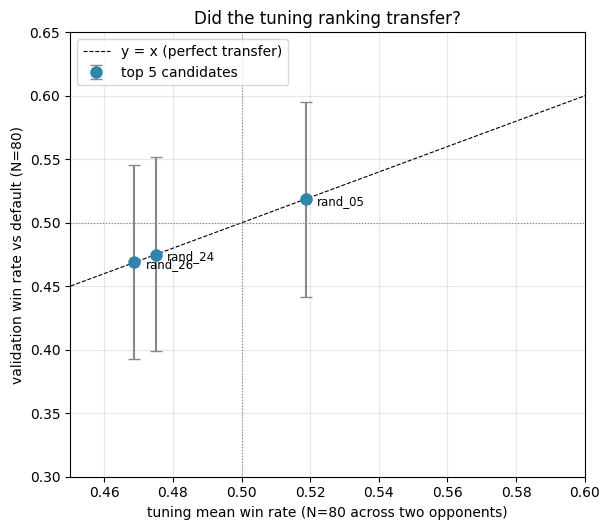

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 5.4))

ax.plot([0.3, 0.7], [0.3, 0.7], color="black", ls="--", lw=0.8,
        label="y = x (perfect transfer)")
ax.axhline(0.5, color="gray", ls=":", lw=0.8)
ax.axvline(0.5, color="gray", ls=":", lw=0.8)

errs = np.array([[r["win_rate"] - r["lo"], r["hi"] - r["win_rate"]]
                 for _, r in val.iterrows()]).T
ax.errorbar(val["mean_winrate"], val["win_rate"], yerr=errs,
            fmt="o", color="#2E86AB", capsize=4, markersize=8,
            ecolor="#888", label="top 5 candidates")
for _, r in val.iterrows():
    ax.annotate(r["tag"], (r["mean_winrate"], r["win_rate"]),
                textcoords="offset points", xytext=(8, -4), fontsize=8.5)
ax.set_xlim(0.45, 0.60)
ax.set_ylim(0.30, 0.65)
ax.set_xlabel("tuning mean win rate (N=80 across two opponents)")
ax.set_ylabel(f"validation win rate vs default (N={N_VAL_GAMES})")
ax.set_title("Did the tuning ranking transfer?")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
out = settings.FIGURES_DIR / "exp_tune_transfer.png"
fig.savefig(out, dpi=120)
print("saved", out)
plt.show()


### Validation bar chart

Same data, plotted as a horizontal bar with Wilson 95% intervals and the
Bonferroni threshold marked. This is the chart I would put in the report.


saved C:\Git\AI801Project\cache\figures\exp_tune_validation.png


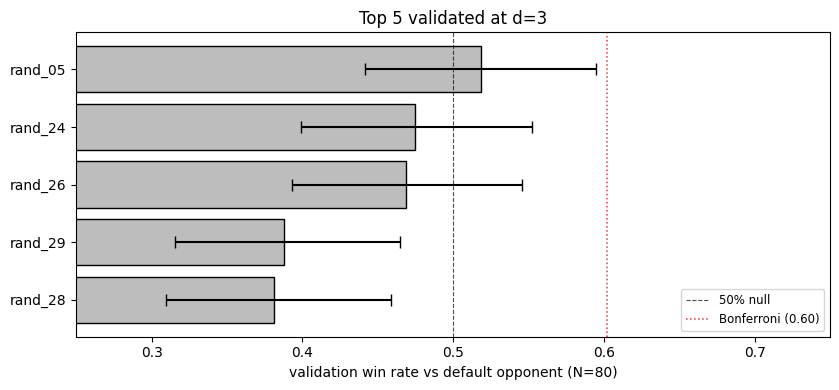

In [12]:
v = val.sort_values("win_rate", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.5, 4))
ypos  = np.arange(len(v))
errs  = np.array([[r["win_rate"] - r["lo"], r["hi"] - r["win_rate"]]
                  for _, r in v.iterrows()]).T
colors = ["#2E86AB" if p else "#bdbdbd" for p in v["passes"]]
ax.barh(ypos, v["win_rate"], xerr=errs, color=colors,
        edgecolor="black", capsize=4)
ax.axvline(0.5, color="black", ls="--", lw=0.8, alpha=0.7,
           label="50% null")
ax.axvline(threshold, color="#E63946", ls=":", lw=1.1,
           label=f"Bonferroni ({threshold:.2f})")
ax.set_yticks(ypos)
ax.set_yticklabels(v["tag"])
ax.set_xlabel(f"validation win rate vs default opponent (N={N_VAL_GAMES})")
ax.set_xlim(0.25, 0.75)
ax.set_title(f"Top {TOP_K} validated at d={DEPTH}")
ax.legend(loc="lower right", fontsize=8.5)
fig.tight_layout()
out = settings.FIGURES_DIR / "exp_tune_validation.png"
fig.savefig(out, dpi=120)
print("saved", out)
plt.show()


## Decision

If at least one validated candidate clears the threshold, ship it as
`best_weights_tuned.pkl`. Otherwise persist the defaults under the same
name so downstream code has a single artifact to load regardless of the
outcome.


In [13]:
winners = val[val["passes"]].sort_values("win_rate", ascending=False)

if len(winners) == 0:
    decision = "fallback_defaults"
    best_weights = dict(base)
    print(f"No candidate cleared the Bonferroni threshold ({threshold:.3f}).")
    print("Keeping the default weights.")
else:
    decision = "tuned"
    best_tag     = winners.iloc[0]["tag"]
    best_weights = cand_lookup[best_tag]
    row = winners.iloc[0]
    print(f"Selected candidate: {best_tag}")
    print(f"  validated win rate: {row['win_rate']:.3f}  "
          f"(95% CI [{row['lo']:.3f}, {row['hi']:.3f}])")

print()
for k, v_ in best_weights.items():
    print(f"  {k:>22s}: {v_}")

out_path = settings.cache_path("best_weights_tuned.pkl")
out_path.write_bytes(pickle.dumps({"weights": best_weights,
                                    "decision": decision,
                                    "validation": val.to_dict("records"),
                                    "threshold": threshold}))
print(f"\nsaved -> {out_path}")


No candidate cleared the Bonferroni threshold (0.602).
Keeping the default weights.

                   w_two: 1.0
                 w_three: 10.0
             w_block_two: 1.0
           w_block_three: 8.0
            w_open_three: 0.0
      w_block_open_three: 0.0
                w_center: 0.5
                   w_win: 10000.0

saved -> C:\Git\AI801Project\cache\results\best_weights_tuned.pkl


## Comparison with notebook 03

Side-by-side, this notebook is the stricter version of nb03's expC:

| | nb03 (expC) | nb04 |
|---|---|---|
| tuning depth | 2 | 3 (matches deployment) |
| weights varied | 3 of 7 | 5 of 7 |
| sampling | 18-cell grid + 20 random | 30 random, log-uniform |
| opponents | 1 | 2, ranked by mean |
| validation N per candidate | 80 | 160 |
| Bonferroni threshold | 0.634 | 0.602 |

A null result here is therefore a much stronger statement than a null
result from nb03 alone. A positive result would also be more credible
because the tuning depth matches the deployment depth and the ranking
already accounts for opponent variety.


In [14]:
# Final summary line for the report.
art = pickle.loads(settings.cache_path("best_weights_tuned.pkl").read_bytes())
print("=" * 60)
print(f"nb04 decision: {art['decision']}")
print("=" * 60)
print("weights shipped:")
for k, v in art["weights"].items():
    print(f"  {k:>22s}: {v}")
print()
print(f"Bonferroni threshold used: {art['threshold']:.3f}")
print()
print("validation table:")
pd.DataFrame(art["validation"])[["tag", "win_rate", "lo", "hi", "passes"]]


nb04 decision: fallback_defaults
weights shipped:
                   w_two: 1.0
                 w_three: 10.0
             w_block_two: 1.0
           w_block_three: 8.0
            w_open_three: 0.0
      w_block_open_three: 0.0
                w_center: 0.5
                   w_win: 10000.0

Bonferroni threshold used: 0.602

validation table:


,tag,win_rate,lo,hi,passes
0,rand_05,0.51875,0.441801,0.594820,False
1,rand_24,0.47500,0.399118,0.552055,False
2,rand_26,0.46875,0.393067,0.545899,False
3,rand_28,0.38125,0.309611,0.458458,False
4,rand_29,0.38750,0.315492,0.464783,False
